# KuaiRand: An Unbiased Sequential Recommendation Dataset with Randomly Exposed Videos 

[![LICENSE](https://img.shields.io/badge/license-CC%20BY--SA%204.0-green)](https://github.com/chongminggao/KuaiRand/blob/main/LICENSE)

*KuaiRand* is an unbiased sequential recommendation dataset collected from the recommendation logs of the video-sharing mobile app, [Kuaishou (快手)](https://www.kuaishou.com/cn).  **It is the first recommendation dataset with millions of  intervened interactions of randomly exposed items inserted in the standard recommendation feeds!** 

## Overview:

The following figure gives an example of the dataset. It illustrates a user interaction sequence along with the user's rich feedback signals.

![kuaidata](./figs/KuaiRand.png)

These feedback signals are collected from the two main user interfaces (UI) in Kuaishou APP shown as follows:

<img src="figs/kuaishou-app.png" alt="kuaishou-app" style="display: block;margin: auto;zoom:35%;" />

In the random exposure stage, each recommended video in the dataset has an equal probability being replaced by a random video sampled from an item pools. About $0.37\%$ Interactions are replaced in the final results. 

#### Advantages:

Compared with other datasets with random exposure, KuaiRand has the following advantages:

- ✅ It is the first sequential recommendation dataset with millions of  intervened interactions of randomly exposed items inserted in the standard recommendation feeds.
- ✅ It has the most comprehensive side information including explicit user IDs, interaction timestamps, and rich features for users and items.
- ✅ It has 15 policies with each catered for a special recommendation scenario in Kuaishou App.
- ✅ We introduce 12 feedback signals (e.g., click, like, and view time) for each interaction to describe the user's comprehensive feedback.
- ✅ Each user has thousands of historical interactions on average.
- ✅ It has three versions to support various research directions in recommendation.

----

## Three Versions and Suggestions:

We release three versions of KuaiRand for different usage:

- **KuaiRand-27K (23GB logs +23GB features):** the complete KuaiRand dataset that has over 27K users and 32 millions videos.
- **KuaiRand-1K  (829MB logs + 3.5GB features):** randomly sample 1,000 users from *KuaiRand-27K*, then remove all irrelevant videos. There are 4 millions videos rest. 
- **KuaiRand-Pure  (184MB logs + 10MB features):** only keeps the logs for the 7582 videos in the candidate pool. 

The *user_id* and *video_id* are re-indexed. A visualization of their ID spaces is shown as follows.

![kuaidata](./figs/three-version.png)





####  3️⃣ Descriptions of the fields in `video_features_basic.csv`

| Field Name:    | Description                                                  | Type  | Example       |
| -------------- | ------------------------------------------------------------ | ----- | ------------- |
| video_id       | The ID of the video.                                         | int64 | 3784          |
| author_id      | The ID of the author of this video. In the range of [0, 8839734] | int64 | 441           |
| video_type     | Type of this video (NORMAL or AD).                           | str   | "NORMAL"      |
| upload_dt      | Upload date of this video.                                   | str   | "2020-07-08"  |
| upload_type    | The upload type of this video.                               | str   | "ShortImport" |
| visible_status | The visible state of this video on the APP now.              | int   | 1             |
| video_duration | The time duration of this duration (in millisecond).         | Int64 | 17200.0       |
| server_width   | The width of this video on the server.                       | int64 | 720           |
| server_height  | The height of this video on the server.                      | int64 | 1280          |
| music_id       | Background music ID of this video.                           | int64 | 989206467     |
| music_type     | Background music type of this video.                         | int64 | 4             |
| tag            | A list of key categories (labels) of this video.             | str   | "12,65"       |

---




In [2]:
import sys, os
path_to_root = os.path.abspath("../../")

if path_to_root not in sys.path:
    sys.path.append(path_to_root)

from models.clustering import DeepEmbeddingClustering
from models.decomposition import Autoencoder
from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = None

In [3]:
video_field_descriptions = {
    "video_id": "video_id",
    "video_type": "Type of this video.",
    "upload_type": "The upload type of this video.",
    "visible_status": "The visible state of this video on the APP now.",
    "video_duration": "The time duration of this video (in millisecond).",
    "music_type": "Background music type of this video.",
    "tag": "Video hashtag.",

    "video_display_size": "The display area of this video.",
    "video_duration_range": "The duration range of this video.",
    "video_display_size_range": "The display area range of this video.",
    "video_age": "The age of this video (in days).",
    "video_age_range": "The age range of this video.",
    "author_class": "The class of the author of this video.",
    "song_rank": "The rank of the background music of this video in the music library.",
}

categoricals = [
  "Type of this video.",
  "The upload type of this video.",
  "The visible state of this video on the APP now.",
  "Background music type of this video.",
  "The duration range of this video.",
  "The display area range of this video.",
  "The age range of this video.",
  "The class of the author of this video.",
  "The rank of the background music of this video in the music library.",
  "Video hashtag.",
]

In [4]:
videos  = pd.read_csv("../../data/KuaiRand-1K/data/video_features_basic_1k.csv", parse_dates=["upload_dt"])
interactions = pd.read_csv("../../data/KuaiRand-1K/data/log_standard_4_08_to_4_21_1k.csv", usecols=["video_id", "is_profile_enter", "is_like", "long_view"])
interactions = interactions.groupby('video_id', as_index=False)[['is_profile_enter', 'is_like', 'long_view']].sum()
videos = videos.merge(interactions, on='video_id', how='left').fillna(0).sample(1000000, random_state=42)

# Create a new feature for video duration range
videos['video_duration_range'] = pd.cut(
  videos['video_duration'], 
  bins=[0, 3e4, 6e4, 1.2e5, 1.8e5, 2.4e5, 3e5, 3.6e5, 4.2e5, np.inf], 
  labels=['0-30 seconds', '30-60 seconds', '1-2 minutes', '2-3 minutes', '3-4 minutes', '4-5 minutes', '5-6 minutes', '6-7 minutes', '7+ minutes']
)

# Create a new feature for video display size
videos['video_display_size'] = videos.server_height * videos.server_width
videos['video_display_size_range'] = pd.cut(
  videos['video_display_size'], 
  bins=[0, 1.2e+07, 2.4e+07, 3.6e+07, np.inf], 
  labels=['small', 'small-medium', 'medium-large', 'large']
)

# create a new feature for video age
videos['upload_dt'] = pd.to_datetime(videos['upload_dt'], unit='s', errors='coerce')
videos['video_age'] = (videos.upload_dt.max() - videos['upload_dt']).dt.days

videos['video_age_range'] = pd.cut(
  videos['video_age'], 
  bins=[0, 7, 14, 30, 60, 90, np.inf], 
  labels=['0-7 days', '7-14 days', '14-30 days', '30-60 days', '60-90 days', '90+ days']
)

# Create a new feature for author class based on the number of likes received by their videos
top_creators = {
    'Top 20': [ 162618, 5921989, 1127691, 5294188, 6239090, 4642129, 5097930, 3967151, 5623243, 7497066, 6599534, 3952568, 5536043, 4927033, 6770796, 7136643, 5117904, 3529930, 7055822, 4827122],
    'Top 20-40': [3376439, 5388905, 7311352, 8428816, 5363056, 5199230, 8383105, 7795287, 3503742, 1500262, 8203851, 4494478, 6710390, 78931, 420876, 5507915, 7325453, 4018420, 8443599, 194116],
    'Top 40-60': [7586832, 4052956, 5115904, 8541212, 1864991, 2048237, 7482152, 7490392,  833612, 7294138, 5838090, 1039764, 7642885, 106137, 7532107,  465827,  909536, 3605982, 7542571, 8678],
    'Top 60-80': [7376629, 1704409, 5132825, 6432207, 4921585, 4869820, 6689331, 5309459, 6000758, 7898710, 7897411, 6853179, 6004355, 7997883, 2456727, 6780903, 7163588, 5236343, 5508966, 4256925],
    'Top 80-100': [  59454, 7400255, 4969630, 7350552, 7348269, 8277168, 7699565, 7402091, 7631453, 7564962, 7990110, 1508379, 5198513, 5204448, 642953, 6234226, 5040662, 6643294, 5969836, 5643385]
}
videos.loc[:, 'author_class'] = 'smaller-creator'
for group, creators in top_creators.items():
    videos.loc[videos.author_id.isin(creators), 'author_class'] = group

# Create a new feature for song rank based on the number of likes received by videos using that song
top_songs = {
    'None': [0],
    'Top 20 song': [9107419068, 6201083918, 8953211090, 9156967270, 9056382190, 9084472638, 8911046447, 8759931155, 9212341703, 9001113574, 8514002961, 5128196645, 8871829651,      39883, 5128386736, 8928004161, 8873596998, 9090448530, 8312074764],
    'Top 20-40': [9179209248, 4096626583, 8887918349, 9108660117, 8968932964, 9001314800, 9022650002, 9119097210, 6199377620, 8147298784, 9070399849, 6200169289, 9066327392, 8875890895, 3095969283, 5128480679, 9179004717, 7942400530, 8858015130, 3365310207],
    'Top 40-60': [5127670285, 6821917069, 8918965475, 9190020176, 9118882131, 9156568021, 3151246603, 8857332209, 8847892177, 8525244297, 8851473258, 9013366940, 5127344928, 8033050120, 8084903889, 4045710830, 8863754454, 9144593462, 8991533641, 8465852089],
    'Top 60-80': [9051431556, 8802023739, 9139215406, 8147112553, 9150424395, 8672574101, 8929429655, 8003355658, 5128097221, 8867093581, 9162494612, 8977948330, 9053668018, 4751083022, 8146716262, 8862696427,     116759, 8614173079, 2167228536, 9136006423],
    'Top 80-100': [9146223172, 9034717539, 7751660740, 7097343593, 8836684413, 7090006253, 9035243807, 6592739598, 8862696449, 4720441703, 8480212178, 8000470277, 8399959119, 8931826945, 7655044588, 7688522061, 8981513909, 8871639034, 9138314412, 8514898376]
}
videos.loc[:, 'song_rank'] = 'other'
for group, songs in top_songs.items():
    videos.loc[videos.music_id.isin(songs), 'song_rank'] = group

# Create a new feature for the first tag of the video
videos['tag'] = videos.tag.apply(lambda x: (str(x).split(',') if pd.notna(x) else [-1])[0]).astype(str)

videos.rename(columns=video_field_descriptions, inplace=True)

# data = pd.get_dummies(videos[video_field_descriptions.values()], columns=categoricals, prefix_sep=': ', drop_first=False).astype('Int64')

videos[['is_profile_enter', 'is_like', 'long_view']] = videos[['is_profile_enter', 'is_like', 'long_view']].replace(0, np.nan)

In [5]:
videos.head()

,video_id,author_id,Type of this video.,upload_dt,The upload type of this video.,The visible state of this video on the APP now.,The time duration of this video (in millisecond).,server_width,server_height,music_id,Background music type of this video.,Video hashtag.,is_profile_enter,is_like,long_view,The duration range of this video.,The display area of this video.,The display area range of this video.,The age of this video (in days).,The age range of this video.,The class of the author of this video.,The rank of the background music of this video in the music library.
2835880,2835912,8415715,NORMAL,2022-04-10,Kmovie,0.0,13216.0,1280.0,720.0,9156461889,9.0,2,NaN,NaN,NaN,0-30 seconds,921600.0,small,28,14-30 days,smaller-creator,other
3312733,3312765,4510798,NORMAL,2022-05-03,ShortImport,0.0,9750.0,720.0,1280.0,9417207853,9.0,19,NaN,NaN,NaN,0-30 seconds,921600.0,small,5,0-7 days,smaller-creator,other
3526143,3526175,2029701,NORMAL,2022-04-27,Web,0.0,15300.0,720.0,1280.0,9346732081,9.0,12,NaN,NaN,NaN,0-30 seconds,921600.0,small,11,7-14 days,smaller-creator,other
1739305,1739337,1821753,NORMAL,2022-04-25,LongCamera,0.0,23920.0,720.0,1280.0,9322566817,9.0,11,NaN,NaN,NaN,0-30 seconds,921600.0,small,13,7-14 days,smaller-creator,other
2008005,2008037,6831457,NORMAL,2022-04-28,LongPicture,0.0,0.0,1080.0,1080.0,7604631711,9.0,67,NaN,NaN,NaN,NaN,1166400.0,small,10,7-14 days,smaller-creator,other


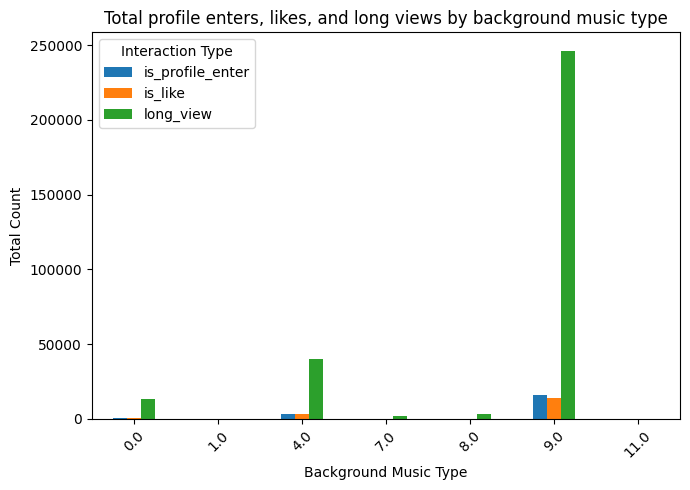

,is_profile_enter,is_like,long_view
Background music type of this video.,,,
0.0,415.0,344.0,13314.0
1.0,0.0,0.0,1.0
4.0,3500.0,3030.0,39930.0
7.0,158.0,150.0,2150.0
8.0,262.0,189.0,3379.0
9.0,16284.0,13746.0,246323.0
11.0,7.0,13.0,129.0


In [14]:
videos.groupby('Background music type of this video.')[['is_profile_enter', 'is_like', 'long_view']].sum().plot.bar(figsize=(7, 5))
plt.title('Total profile enters, likes, and long views by background music type')
plt.xlabel('Background Music Type')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend(title='Interaction Type')
plt.tight_layout()
plt.show()

videos.groupby('Background music type of this video.')[['is_profile_enter', 'is_like', 'long_view']].sum()

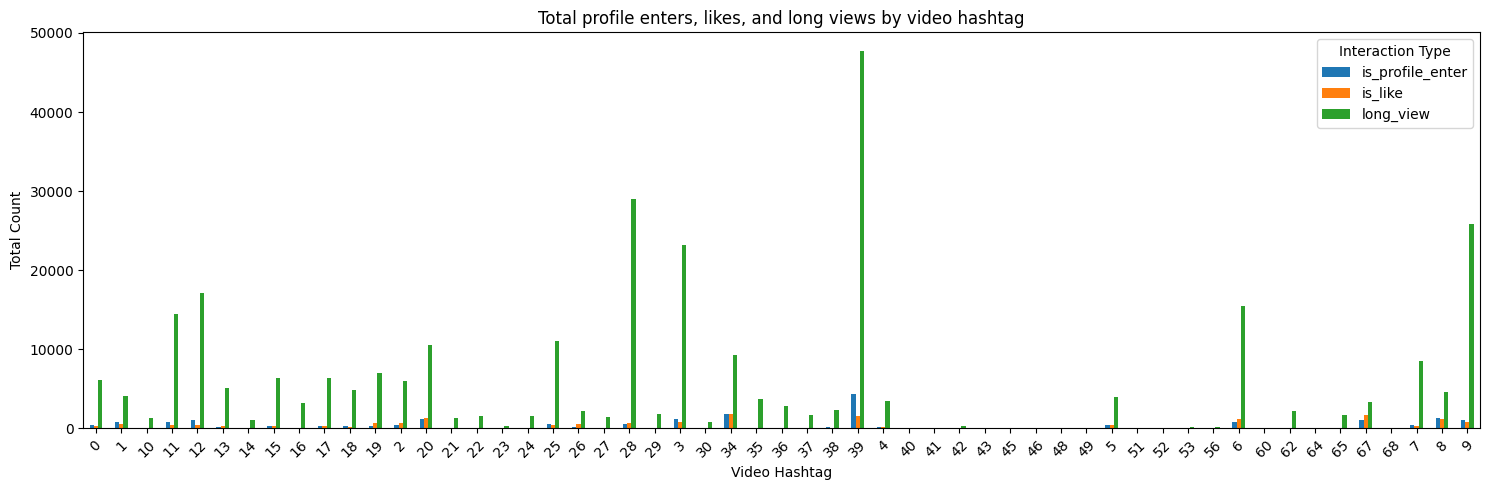

,is_profile_enter,is_like,long_view
Video hashtag.,,,
0,423.0,323.0,6135.0
1,763.0,495.0,4109.0
10,83.0,51.0,1356.0
11,840.0,470.0,14394.0
12,1034.0,421.0,17165.0
13,141.0,240.0,5136.0
14,34.0,59.0,986.0
15,245.0,289.0,6352.0
16,86.0,42.0,3177.0


In [15]:
videos.groupby('Video hashtag.')[['is_profile_enter', 'is_like', 'long_view']].sum().plot.bar(figsize=(15, 5))
plt.title('Total profile enters, likes, and long views by video hashtag')
plt.xlabel('Video Hashtag')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend(title='Interaction Type')
plt.tight_layout()
plt.show()

videos.groupby('Video hashtag.')[['is_profile_enter', 'is_like', 'long_view']].sum()

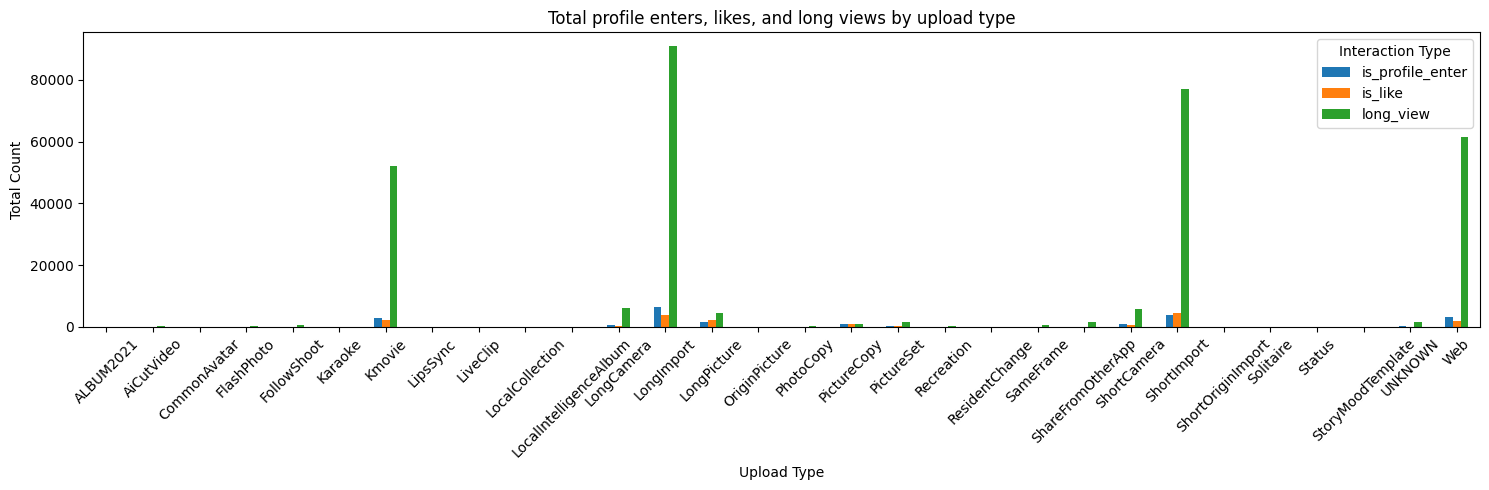

,is_profile_enter,is_like,long_view
The upload type of this video.,,,
ALBUM2021,0.0,0.0,0.0
AiCutVideo,22.0,21.0,340.0
CommonAvatar,0.0,0.0,0.0
FlashPhoto,28.0,22.0,187.0
FollowShoot,53.0,54.0,509.0
Karaoke,0.0,2.0,4.0
Kmovie,2982.0,2288.0,52122.0
LipsSync,2.0,1.0,21.0
LiveClip,4.0,1.0,29.0


In [16]:
videos.groupby('The upload type of this video.')[['is_profile_enter', 'is_like', 'long_view']].sum().plot.bar(figsize=(15, 5))
plt.title('Total profile enters, likes, and long views by upload type')
plt.xlabel('Upload Type')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend(title='Interaction Type')
plt.tight_layout()
plt.show()

videos.groupby('The upload type of this video.')[['is_profile_enter', 'is_like', 'long_view']].sum()

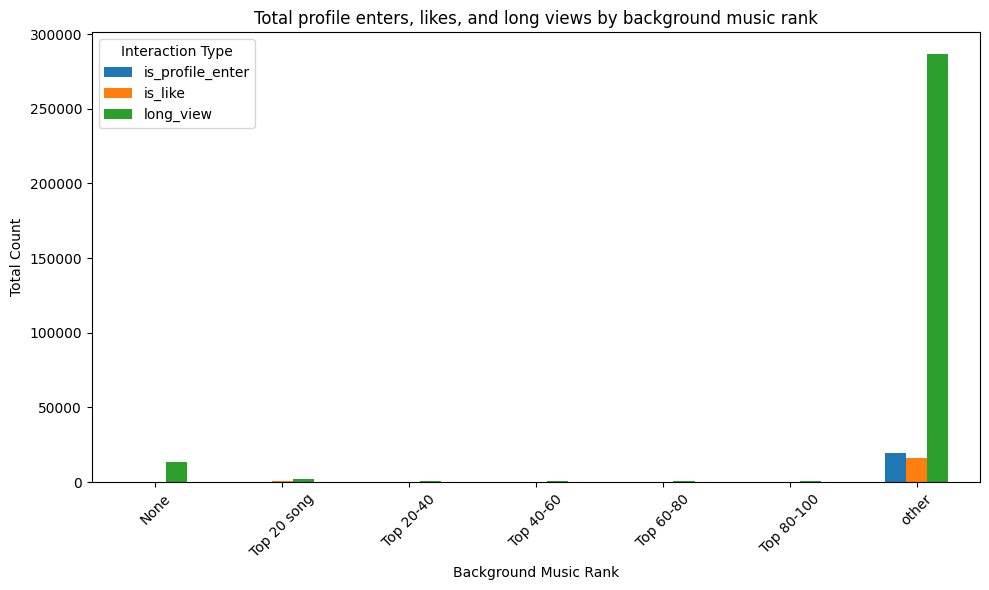

,is_profile_enter,is_like,long_view
The rank of the background music of this video in the music library.,,,
None,420.0,345.0,13370.0
Top 20 song,353.0,433.0,1915.0
Top 20-40,131.0,258.0,924.0
Top 40-60,84.0,195.0,655.0
Top 60-80,80.0,164.0,932.0
Top 80-100,55.0,140.0,559.0
other,19503.0,15937.0,286871.0


In [17]:
videos.groupby('The rank of the background music of this video in the music library.')[['is_profile_enter', 'is_like', 'long_view']].sum().plot.bar(figsize=(10, 6))
plt.title('Total profile enters, likes, and long views by background music rank')
plt.xlabel('Background Music Rank')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend(title='Interaction Type')
plt.tight_layout()
plt.show()

videos.groupby('The rank of the background music of this video in the music library.')[['is_profile_enter', 'is_like', 'long_view']].sum()

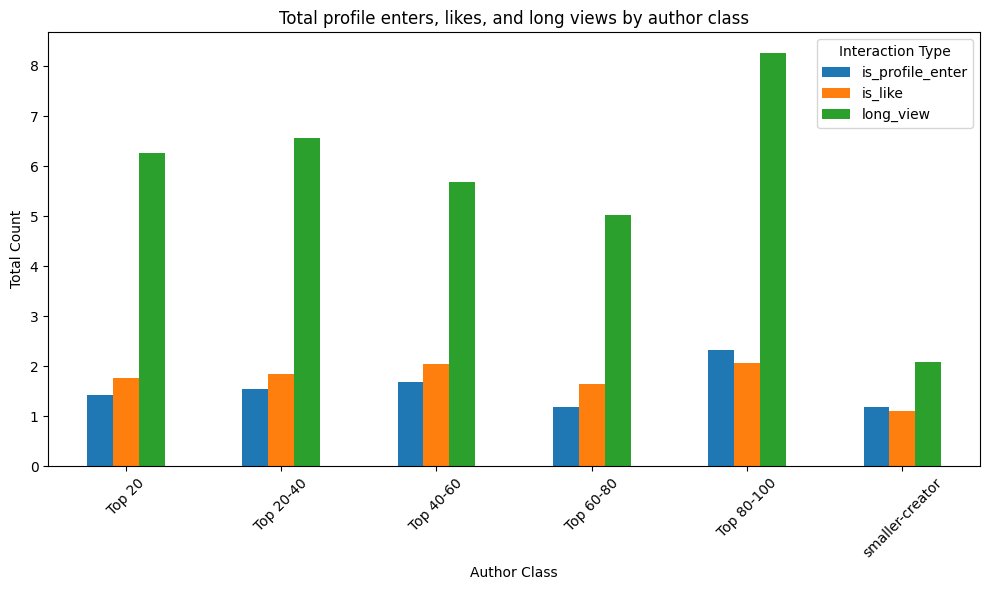

,is_profile_enter,is_like,long_view
The class of the author of this video.,,,
Top 20,1.428571,1.760000,6.257310
Top 20-40,1.541667,1.840426,6.558935
Top 40-60,1.687500,2.054795,5.687075
Top 60-80,1.184211,1.641975,5.014652
Top 80-100,2.333333,2.068966,8.259259
smaller-creator,1.189192,1.108948,2.094294


In [18]:
videos.groupby('The class of the author of this video.')[['is_profile_enter', 'is_like', 'long_view']].mean().plot.bar(figsize=(10, 6))
plt.title('Total profile enters, likes, and long views by author class')
plt.xlabel('Author Class')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend(title='Interaction Type')
plt.tight_layout()
plt.show()

videos.groupby('The class of the author of this video.')[['is_profile_enter', 'is_like', 'long_view']].mean()

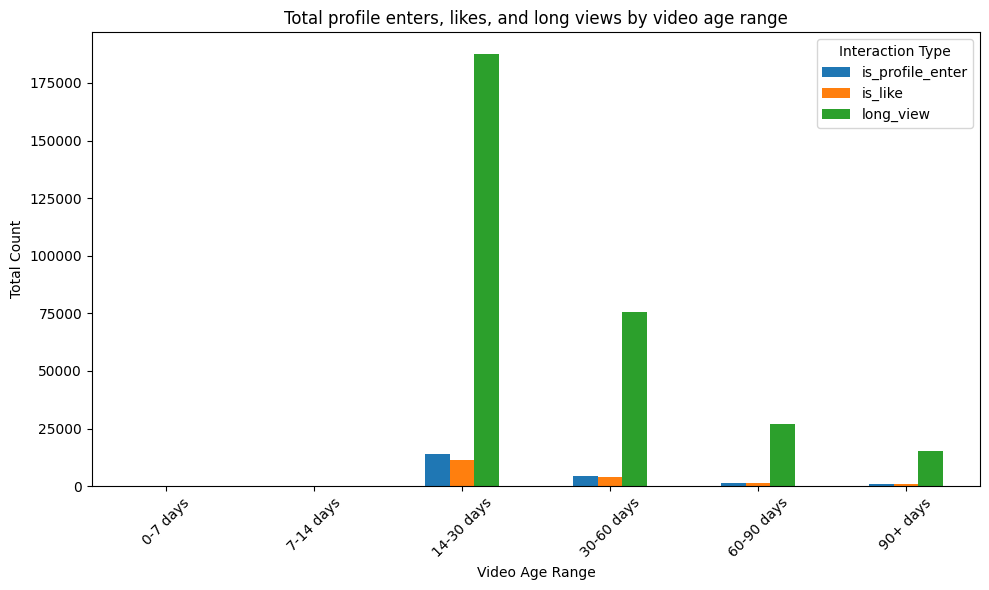

,is_profile_enter,is_like,long_view
The age range of this video.,,,
0-7 days,0.0,0.0,0.0
7-14 days,0.0,0.0,0.0
14-30 days,14073.0,11331.0,187597.0
30-60 days,4380.0,4002.0,75419.0
60-90 days,1336.0,1335.0,27014.0
90+ days,837.0,804.0,15196.0


In [19]:
videos.groupby('The age range of this video.')[['is_profile_enter', 'is_like', 'long_view']].sum().plot.bar(figsize=(10, 6))
plt.title('Total profile enters, likes, and long views by video age range')
plt.xlabel('Video Age Range')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend(title='Interaction Type')
plt.tight_layout()
plt.show()

videos.groupby('The age range of this video.')[['is_profile_enter', 'is_like', 'long_view']].sum()

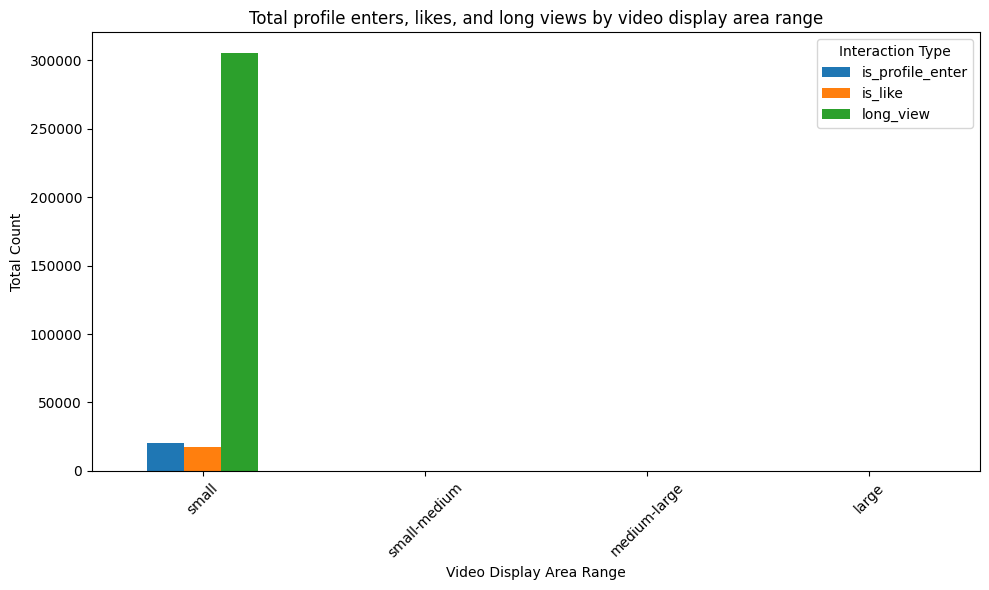

,is_profile_enter,is_like,long_view
The display area range of this video.,,,
small,20541.0,17387.0,305158.0
small-medium,85.0,85.0,67.0
medium-large,0.0,0.0,1.0
large,0.0,0.0,0.0


In [20]:
videos.groupby('The display area range of this video.')[['is_profile_enter', 'is_like', 'long_view']].sum().plot.bar(figsize=(10, 6))
plt.title('Total profile enters, likes, and long views by video display area range')
plt.xlabel('Video Display Area Range')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend(title='Interaction Type')
plt.tight_layout()  
plt.show()

videos.groupby('The display area range of this video.')[['is_profile_enter', 'is_like', 'long_view']].sum()

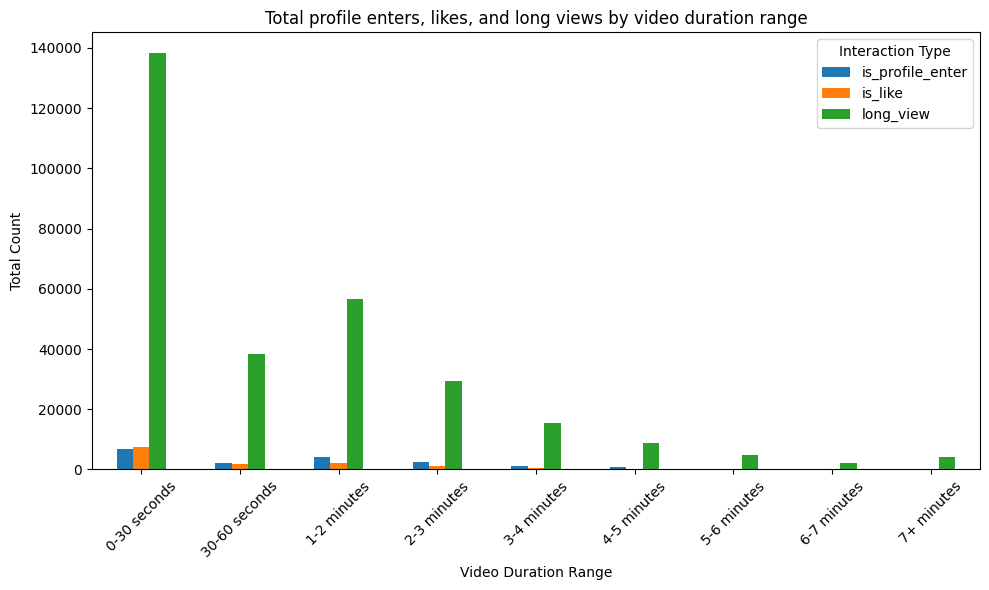

,is_profile_enter,is_like,long_view
The duration range of this video.,,,
0-30 seconds,6693.0,7596.0,138234.0
30-60 seconds,2196.0,1796.0,38504.0
1-2 minutes,4116.0,2192.0,56583.0
2-3 minutes,2362.0,1001.0,29499.0
3-4 minutes,1162.0,554.0,15372.0
4-5 minutes,695.0,263.0,8724.0
5-6 minutes,315.0,154.0,4795.0
6-7 minutes,156.0,67.0,2193.0
7+ minutes,269.0,123.0,4291.0


In [21]:
videos.groupby('The duration range of this video.')[['is_profile_enter', 'is_like', 'long_view']].sum().plot.bar(figsize=(10, 6))
plt.title('Total profile enters, likes, and long views by video duration range')
plt.xlabel('Video Duration Range')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend(title='Interaction Type')
plt.tight_layout()
plt.show()

videos.groupby('The duration range of this video.')[['is_profile_enter', 'is_like', 'long_view']].sum()